# 01 · Acquisition and tracking

Notebook `00` confirmed the collect is usable. This notebook despreads it: acquisition finds which satellites are present and roughly where, and tracking follows them.

## Acquisition and tracking, briefly

Correlating against a satellite's PRN code gives processing gain of about `10·log10(T · R_c)` — for 5 ms of a 10.23 Mcps code, roughly 47 dB — which is what lifts a signal tens of dB below the noise floor into a visible peak. That gain only accrues if two unknowns are right:

| Unknown | Why it is unknown | Resolution |
|---|---|---|
| **Code phase** | proportional to range to the satellite | one sample of the correlation grid |
| **Doppler** | line-of-sight velocity, up to ±5 kHz for a static receiver | one FFT bin, `1 / T_replica` |

**Acquisition** searches that 2-D grid — FFT-based parallel code-phase search across a Doppler bank — and thresholds the peak against a chi-squared noise model. **Tracking** closes loops around the result: a DLL on early/late correlators for code phase, and an FLL then PLL for carrier. Both unknowns drift continuously as the satellite moves, which is why tracking is a loop rather than a repeated search.

## Signal structures

Set `SIGNAL_ID` in the config cell. All four GPS civil signals are listed; the first three are implemented here.

| | GPS L1 C/A | GPS L2C | GPS L5 | GPS L1C |
|---|---|---|---|---|
| **Carrier** | L1, 1575.42 MHz | L2, 1227.60 MHz | L5, 1176.45 MHz | L1, 1575.42 MHz |
| **Components** | `CA` | `CM`, `CL` | `I`, `Q` | `L1CD`, `L1CP` |
| **Chip rate** | 1.023 Mcps | 511.5 kcps each, 1.023 Mcps combined | 10.23 Mcps each | 1.023 Mcps |
| **Primary code period** | 1 ms (1023 chips) | CM 20 ms, CL 1.5 s | 1 ms (10230 chips) | 10 ms (10230 chips) |
| **Multiplexing** | single code | chip-interleaved on alternating slots | co-located, separated in carrier phase (I/Q) | separate codes, power-split 25/75 |
| **Modulation** | BPSK(1) | BPSK(1) | BPSK(10) | L1CD BOC(1,1), L1CP TMBOC(6,1,4/33) |
| **Data** | 50 bps, 20 ms symbols on `CA` | 50 bps → 25 sps, 20 ms symbols on `CM` | 50 bps → 100 sps, 10 ms symbols on `I` | 50 bps → 100 sps, 10 ms symbols on `L1CD` |
| **Pilot** | none | `CL` (dataless) | `Q` (dataless) | `L1CP` (dataless) |
| **Secondary / overlay code** | none | none | NH10 on `I`, NH20 on `Q` | 1800-chip overlay on `L1CP`, 18 s |
| **Carrier loop runs on** | `CA` | `CM`, then `CL` once resolved | `Q` | `L1CP` |
| **Supported here** | yes | yes | yes | **not yet** |

L1C is not implemented: `gnss_tools.signals.gps_l1c` carries only the L1CP Weil code, without the chip rate, the L1CD code, the TMBOC subcarrier or CNAV-2 support, and it is not in the signal catalog. It is in the table because the structure it shares with the others — a dataless pilot carrying a long overlay, a data component with a short symbol — is exactly what the machinery below is built around.

**Terms used above.** A *component* is one spreading code within a signal. A *pilot* carries no navigation data, so its sign is constant and the carrier loop can use a four-quadrant discriminator instead of a Costas one — worth about 6 dB. A *secondary* (or overlay, or tiered) code multiplies each primary code period by one further chip; until it is synchronised and wiped off, it flips sign exactly like data and caps coherent integration at one primary period.

> **Design note.** A signal is described by data, not by a bespoke correlator: `utils.code_components` states how each code occupies the chip clock, and a `LoopDiscriminatorPolicy` states which component drives which loop. One `utils.tracking_channel.TrackingChannel` serves every signal. Acquisition and tracking policy live apart from the signal definition, in `ACQUISITION_POLICIES` / `TRACKING_POLICIES`, keyed by `signal_type_id`.

## 1. Imports

`GpsL1CA`, `GpsL2C` and `GpsL5` are classes, not enum members: instantiating one for a PRN — `GpsL5(prn=1)` — builds that satellite's code set.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

import utils
from utils import bpsk_acquisition, collect_metadata_utils, sample_streaming, tracking_channel
from utils.signal_interfaces import (
    GpsL1CA,
    GpsL2C,
    GpsL5,
    build_acquisition_code_params,
    build_signals,
    create_tracking_channels,
    resolve_acquisition_ambiguities,
)

utils.plotting.setup_default_plotting()

/opt/anaconda3/envs/gnss_tracking_example/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

### Acquisition: two coherent durations

Acquisition has two independent lengths, and conflating them is the usual source of confusion:

| Parameter | What it is | What it sets |
|---|---|---|
| `coherent_duration_replica_ms` | length of the local replica, and therefore the FFT. The correlation is circular, so it must be a whole number of code periods. | Doppler **grid spacing**, `1 / T_replica` |
| `coherent_duration_sample_ms` | how much live data enters one coherent sum. Each block is zero-padded out to the replica length. `None` means "the whole replica". | Doppler **response width**, `1 / T_coherent` |
| `num_blocks` | how many such sums are combined by square law | detection sensitivity; sign flips *between* blocks are harmless |

Coherent integration only accrues gain while the accumulated sign is constant. The navigation symbol flips it (20 ms on L1 C/A and L2 CM, 10 ms on L5 I), and so does an un-stripped secondary code. Separating the two lengths lets the replica stay long — a fine Doppler grid — while each coherent block stays short enough to sit inside one symbol whatever the unknown symbol alignment turns out to be. The figure in step 3 draws this.

Per signal:

- **L1 C/A** — a 5 ms replica is 5 code periods; nav symbols are 20 ms, so 5 ms of coherent integration is clear of a boundary wherever it lands.
- **L2C** — acquires on CM, whose 20 ms code period *is* its CNAV symbol. A full-length coherent sum at an arbitrary alignment straddles a boundary, and the failure is quiet: the peak does not vanish, it shifts a bin and reports a confident but wrong seed. Four 5 ms blocks put at most one boundary in any block.
- **L5** — acquires on Q × NH20, folding the overlay into the replica rather than fighting it. That makes the acquisition code 20 ms, so 5 ms × 4 applies exactly as for L2C, and the recovered code phase carries the NH20 counter outright.

`p_fa_total` is the false-alarm probability over the whole search grid, not per cell.

### Fine search

`fine_search_factors` is `(code_phase_factor, doppler_factor)` — how finely to sub-divide each search bin. `(1, 4)` leaves code phase on the sample grid and tests Doppler at quarter-bin spacing, cutting the worst-case Doppler error to a quarter at four times the cost. `None` means `(1, 1)`.

Whether it is worth it depends on whether the plain grid already seeds tracking tightly enough for the FLL to pull in; step 4 prints both error ranges so you can judge. Code-phase sub-division is not implemented yet and raises rather than silently doing nothing.

### Tracking

- **`COHERENT_DURATION_MS`** — the epoch the discriminators see and the period the loop gains are built for. It must divide every component's symbol period; the channel rejects a value that does not, at construction. Epochs are anchored to code-phase multiples of this value, so the tiling is independent of where acquisition landed.
- **`TRACK_DURATION_MS`** — how much of the collect to track.
- **`BUFFER_DURATION_MS`** — disk read granularity; affects speed only.
- **`START_TRACKING_IN_PLL_MODE`** — start in PLL or FLL. FLL tolerates a much looser Doppler seed, so the default starts there and hands over once the prompt history is coherent.

In [2]:
# ----- Signal and collect -----
SIGNAL_ID = GpsL5  # GpsL1CA, GpsL2C, or GpsL5

# Index into the experiment list printed by the next cell.  As of this writing:
#   0  20230324_SURGE_flight2_boulderresrvoir  marginal: 092021 was captured with
#      essentially no gain, and the rest yield at most one satellite mid-file.
#   1  20230417_SURGE_L5AERORooftop            acquires 5 satellites in 20 ms.
EXPERIMENT_INDEX = 1

# ----- Acquisition -----
# See the markdown above for why the replica and sample coherent durations differ.
ACQ_SETTINGS = {
    GpsL1CA: dict(
        coherent_duration_replica_ms=5, coherent_duration_sample_ms=None, num_blocks=4,
        p_fa_total=1e-3, fine_search_factors=None,
    ),
    GpsL2C: dict(
        coherent_duration_replica_ms=20, coherent_duration_sample_ms=5.0, num_blocks=4,
        p_fa_total=1e-3, fine_search_factors=None,
    ),
    GpsL5: dict(
        coherent_duration_replica_ms=20, coherent_duration_sample_ms=5.0, num_blocks=4,
        p_fa_total=1e-3, fine_search_factors=None,
    ),
}
DOPPLER_SEARCH_HZ = 5000  # +/- this; widen for a moving receiver

# ----- Tracking -----
BUFFER_DURATION_MS = 100        # disk read granularity; affects speed, not results
COHERENT_DURATION_MS = 5        # must divide every component's symbol period
TRACK_DURATION_MS = 10000
START_TRACKING_IN_PLL_MODE = False  # FLL first; it tolerates a loose Doppler seed

print(f"Signal type: {SIGNAL_ID.signal_type_id}")

Signal type: GPS_L5


## 3. Resolve the collect, and see the dwell layout

The chosen signal knows its band (`GpsL5` → `"L5"`), so the collect is selected by searching the experiment for a channel carrying it.

The cell then checks samples per chip. The correlator advances its chip index once per sample, so below about two samples per chip it silently skips chips rather than failing — worth an explicit error. A 10.23 Mcps signal therefore needs ≥ ~20 Msps.

Finally it draws the dwell layout described in step 2: on the left, the coherent blocks and their zero-padding inside the FFT window, with symbol boundaries drawn at a deliberately arbitrary offset — because acquisition does not know the symbol alignment. Notice that at most one boundary can fall inside any one block, and only some blocks are affected. On the right, the Doppler grid against the coherent response: a short coherent duration widens the response without widening the grid.

In [3]:
collects_dir = utils.environment_variables.get_collects_path()
# list_experiment_names keeps only subdirectories, so stray files (e.g. macOS `._`
# AppleDouble sidecars on exFAT volumes) cannot shift EXPERIMENT_INDEX.
available_experiment_names = collect_metadata_utils.list_experiment_names(collects_dir)
print("Available experiments:", ", ".join(available_experiment_names))

if EXPERIMENT_INDEX >= len(available_experiment_names):
    raise IndexError(
        f"EXPERIMENT_INDEX={EXPERIMENT_INDEX} but only {len(available_experiment_names)} "
        f"experiment(s) are present under {collects_dir}."
    )
experiment_name = available_experiment_names[EXPERIMENT_INDEX]
experiment_dir = collects_dir / experiment_name
print(f"Selected experiment: {experiment_name}")

metadata_filepath = experiment_dir / "metadata.yml"
metadata = collect_metadata_utils.load_experiment_metadata_from_file(
    metadata_filepath, print_summary=True
)

# Find a collect whose channel carries the band this signal rides on.
target_band = SIGNAL_ID.link.id.value
candidate_collect_ids = [
    cid for cid in metadata.collect_ids
    if target_band in metadata.channel_configurations[
        metadata.collects[cid].channel_config_id
    ].band_ids
]
if not candidate_collect_ids:
    raise RuntimeError(
        f"No collect found for target band {target_band!r}. "
        f"Bands present in this experiment: {sorted(metadata.band_ids)}"
    )

collect_id = candidate_collect_ids[0]  # index into candidate_collect_ids to change
band_id = target_band
collect_config = metadata.collects[collect_id]
channel_config = metadata.channel_configurations[collect_config.channel_config_id]
band_config = metadata.band_configurations[band_id]

samp_rate = channel_config.samp_rate
sample_params = channel_config.sample_params
inter_freq_hz = band_config.inter_freq
collect_filepath = experiment_dir / collect_config.filename

print(f"Selected collect_id={collect_id}, band_id={band_id}")
print(f"Collect filepath: {collect_filepath}")
print(f"Sample rate: {samp_rate} Hz")

# The correlator steps the chip index once per sample, so below ~2 samples per
# chip it skips chips rather than failing loudly.
chip_rate = SIGNAL_ID.tracking_code_rate_chips_per_sec
samples_per_chip = samp_rate / chip_rate
print(f"Chip rate: {chip_rate/1e6:.3f} Mcps  ->  {samples_per_chip:.2f} samples/chip")
if samples_per_chip < 2.0:
    raise RuntimeError(
        f"Sample rate {samp_rate/1e6:.1f} Msps gives only {samples_per_chip:.2f} samples per "
        f"chip at {chip_rate/1e6:.3f} Mcps. The correlator needs at least ~2; "
        "this collect cannot be used for this signal without resampling."
    )

Available experiments: 20230324_SURGE_flight2_boulderresrvoir, 20230417_SURGE_L5AERORooftop
Selected experiment: 20230417_SURGE_L5AERORooftop
Available bands: L5
Available collects:
  20230417_103222_BALLOON: L5
Selected collect_id=20230417_103222_BALLOON, band_id=L5
Collect filepath: /Volumes/JX_SSD/Desktop/CU_Boulder/Summer_2026/HERON/COLLECTS/20230417_SURGE_L5AERORooftop/20230417_103222_000000_BALLOON_1176.45_22.0.sc8
Sample rate: 22000000 Hz
Chip rate: 10.230 Mcps  ->  2.15 samples/chip


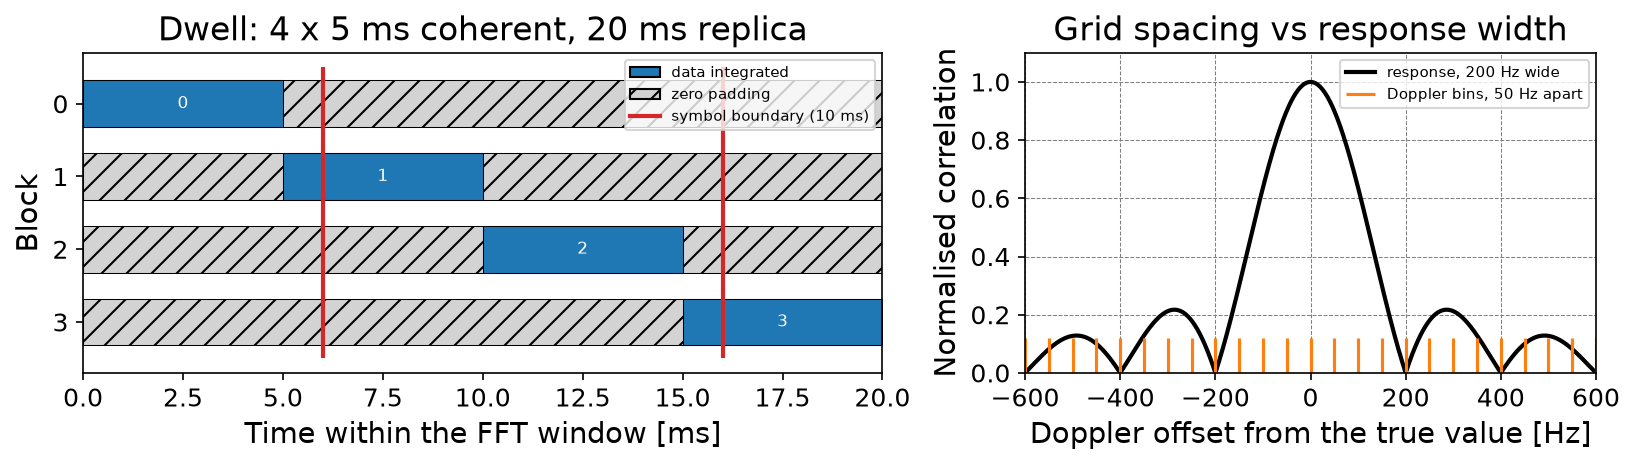

In [4]:
acq_settings = ACQ_SETTINGS[SIGNAL_ID]

acq_config = bpsk_acquisition.AcquisitionConfiguration(
    coherent_duration_replica_ms=acq_settings["coherent_duration_replica_ms"],
    coherent_duration_sample_ms=acq_settings["coherent_duration_sample_ms"],
    num_blocks=acq_settings["num_blocks"],
    sample_rate=samp_rate,
    min_search_doppler_hz=-DOPPLER_SEARCH_HZ,
    max_search_doppler_hz=DOPPLER_SEARCH_HZ,
    fine_search_factors=acq_settings["fine_search_factors"],
)

# Shortest symbol among the signal's components -- the boundary the coherent
# blocks have to avoid straddling.  Dataless pilots have none.
symbol_periods = [
    c.symbol_period_ms
    for c in SIGNAL_ID(prn=1).code_set.components
    if c.symbol_period_ms is not None
]
shortest_symbol_ms = min(symbol_periods) if symbol_periods else None

fig = plt.figure(figsize=(11, 3.2), dpi=150)
utils.plotting.plot_acquisition_dwell_layout(
    fig, acq_config,
    symbol_period_ms=shortest_symbol_ms,
    # Acquisition does not know the symbol alignment; draw an arbitrary one.
    symbol_phase_ms=0.6 * (shortest_symbol_ms or 0.0),
)
plt.tight_layout()
plt.show()

## 4. Acquisition

One dwell of `num_blocks × coherent_duration_sample_ms` is read and searched against every PRN.

The cell first prints the **search resolution** — the worst-case error in the seed acquisition will hand to tracking, in code phase (also as a range error in metres) and in Doppler. If `fine_search_factors` is set, both the plain and the refined figures are shown, which is how to decide whether the extra passes are worth their cost.

Results come back as a table. The **detection threshold is one number for the whole sweep** — it depends only on the per-cell false-alarm rate and `num_blocks`, not on the satellite — so it is stated once in the header rather than repeated per row. Each row gives the peak in **dB above the expected noise level**, so 0 dB is the noise floor and the threshold is directly comparable. Doppler and code phase are filled in only where a peak was actually detected; elsewhere the peak is just the noise maximum and its location means nothing.

Code phase is ambiguous **modulo the period of the code that was correlated against**, and that modulus is in the column header. For L5 acquired on Q × NH20 it is 20 ms; for L1 C/A, 1 ms.

**Ambiguity resolution.** Anything the dwell could not locate is resolved afterwards. L2C acquires on CM's 20 ms period, leaving CL's 1.5 s code 75× longer and unlocated, so the 75 candidates are scored against the same dwell. L1 C/A and L5-as-configured have nothing left, and this returns an empty dict.

Not every detection is real: at `p_fa_total = 1e-3` across 32 PRNs, expect a spurious one occasionally. It will fail to hold lock, which step 6 makes visible.

In [5]:
signals = build_signals(SIGNAL_ID)
acq_code_params = build_acquisition_code_params(SIGNAL_ID, signals)

print(acq_config.search_resolution_summary())
print()

# Read the full coherent x non-coherent dwell.
acq_buffer_duration_ms = acq_config.acq_total_duration_ms
acq_buffer_size_samples = int(samp_rate * acq_buffer_duration_ms / 1e3)
byte_buffer = bytearray(
    sample_streaming.compute_sample_array_size_bytes(
        acq_buffer_size_samples, sample_params.bit_depth, sample_params.is_complex
    )
)
samples = np.zeros(acq_buffer_size_samples, dtype=np.complex64)
baseband_samples = np.zeros(acq_buffer_size_samples, dtype=np.complex64)

# Read -> decode -> mix to baseband -> remove DC, as in notebook 00 step 4.
with open(collect_filepath, "rb") as f:
    f.readinto(byte_buffer)

sample_streaming.convert_to_complex64_samples(byte_buffer, samples, sample_params)
sample_streaming.mixdown_samples(
    samples,
    baseband_samples,
    samp_rate,
    initial_phase_cycles=0.0,
    freq_hz=inter_freq_hz,
)
baseband_samples -= np.mean(baseband_samples)

acq_results = bpsk_acquisition.run_acquisition(
    sample_block=baseband_samples,
    sample_block_uptime_epoch_ms=0.0,
    acq_config=acq_config,
    code_parameters=acq_code_params,
    # Grid-wide, not per-cell: the right per-cell value depends on sample rate,
    # replica duration and Doppler range, so a hard-coded one stops meaning what
    # it did as soon as any of those change.  Sidak conversion happens inside.
    prob_false_alarm_total=acq_settings["p_fa_total"],
    print_progress=True,
    noise_var_method="abscorrvar",
)

acquired_signal_ids = sorted(
    sid for sid, result in acq_results.items() if result.signal_detected
)
print(f"\nAcquired ({SIGNAL_ID.signal_type_id}): {', '.join(acquired_signal_ids) or 'none'}")

# Resolve whatever the dwell could not locate (L2C's CL block); empty otherwise.
ambiguity_resolutions = resolve_acquisition_ambiguities(
    SIGNAL_ID,
    signals,
    acq_results,
    baseband_samples,
    acq_config,
)
for sid, resolution in sorted(ambiguity_resolutions.items()):
    status = "resolved" if resolution.resolved else "UNRESOLVED"
    print(f"  {sid}: block {resolution.best_index} ({status}, "
          f"confidence {resolution.confidence:.2f})")

Search grid: code phase 45.5 ns/bin (22.0 Msps), Doppler 50.0 Hz/bin
  plain search    -> code phase +/-22.7 ns (+/-6.8 m), Doppler +/-25.0 Hz

Detection threshold: 9.30 dB above noise (p_fa 0.001 over 88,000,000 cells/PRN)

  PRN    SNR [dB]  Doppler [Hz] Code phase [ms, mod 20]
  ----- --------- ------------- ----------------------
  G01        24.6         -2000                 17.566
  G02         8.4             -                      -
  G03         8.3             -                      -
  G04         8.3             -                      -
  G05         8.5             -                      -
  G06         8.2             -                      -
  G07         9.1             -                      -
  G08        10.6         -4850                  8.305
  G09         8.4             -                      -
  G10         9.4          -550                 13.900
  G11         8.3             -                      -
  G12         8.3             -                      -
  G1

## 5. Acquisition results

The table says *what* was found; this says how good it looks. One curve per acquired satellite: correlation power against code delay, taken at that satellite's own peak Doppler bin, with delay measured relative to its own peak so the shapes line up.

Power is in **dB above the expected noise level** — the same scale as the SNR column above — so each noise floor sits at 0 dB and each peak reads its own SNR. The dashed line is the detection threshold, which is one number for the whole sweep.

**A real acquisition** is a sharp peak at delay 0, far above the line, falling to a flat floor within about a chip either side. **A false one** is a low, shapeless bump that barely clears it. On the rooftop collect this separates G01/G14/G30 from G08/G10 much more plainly than the table does — the latter two sit within ~1 dB of the threshold and look nothing like a correlation peak.

**Multipath** lives in this dimension. A reflection is always *delayed* relative to the direct path, so it shows as asymmetry about zero — a shoulder on the late side, or a broadened, flattened peak — rather than as a change in peak height. Resolution is coarse here: at 22 Msps against a 10.23 Mcps code there are only 2.15 samples per chip, so the ideal ±1 chip triangle spans about 4 samples and multipath appears across a handful of points.

> **But do not read the asymmetry you see below as multipath.** With 2.15 samples per chip the true peak almost never lands exactly on a sample, so its two neighbours are unequal purely from where the sampling grid fell. Measured here, the late-minus-early difference is −6.4 dB for G01, **+5.8 dB** for G14 and −0.8 dB for G30 — random in sign, which is the fingerprint of sub-sample placement, not of multipath. Real multipath skews *late* consistently, across satellites and across time. One dwell cannot tell them apart; a sequence of dwells can.

> This cell needs the full code-delay axis, which `run_acquisition` keeps by default (`save_corr_doppler_window_bins=1` narrows the *Doppler* axis only). Passing `save_corr_doppler_window_bins=None` keeps everything, at ~700 MB per PRN.

In [ ]:
fig = plt.figure(figsize=(11, 5), dpi=150)
utils.plotting.plot_acquisition_code_phase_slices(fig, acq_results)
plt.show()

## 6. Tracking

One channel per acquired satellite, seeded from its acquisition result, then the collect is streamed buffer by buffer. Each channel correlates one 1 ms interval at a time, folds `COHERENT_DURATION_MS` of them into an epoch (wiping off the secondary code between intervals), and runs its discriminators once per epoch:

- **DLL** — normalised early-minus-late over correlators at ±`EPL_chip_spacing`; an unequal early/late pair means the replica is off in code phase.
- **PLL** — Costas phase discriminator on the carrier component, four-quadrant once the component is a confirmed dataless pilot.
- **FLL** — frequency error over the epoch. Coarser than the PLL but unambiguous over a much wider range, so tracking starts here.

### Loop bandwidths

Each `*_bandwidth_hz` trades responsiveness against noise: wider follows dynamics and a poor seed but admits more noise; narrower gives cleaner estimates but pulls in slowly and loses lock more readily. A discrete loop also stays well damped only while bandwidth × update period stays small, so extending `COHERENT_DURATION_MS` tightens the usable bandwidth proportionally.

Defaults suit a static antenna. Try `PLL_bandwidth_hz` at 5 and at 50 and compare step 6.

### After lock

### Where epochs start

Acquisition seeds an arbitrary code phase, so an epoch grid begun there would sit at an arbitrary offset — and on L5 a 5 ms epoch started at, say, code phase 3 ms crosses I's 10 ms CNAV symbol on every other epoch.

Epochs therefore **open on a symbol boundary** — a code phase that is a multiple of the symbol period. The period used is the shortest symbol among *all* components, not the one the loops run on: on L5 the carrier loop uses the dataless Q pilot, which has no symbol, while I's 10 ms CNAV symbol is what the shared epoch must respect.

Anchoring on the symbol period is stronger than anchoring on the epoch length. Both avoid straddling, but only this one puts epoch zero on symbol zero, so navigation symbols can later be read straight off the epoch index instead of needing their own alignment search. Seeded at 2.34 ms with 5 ms epochs, intervals run 3, 4, 5, … and the first epoch opens at **10 ms** — not 3, and not 5.

A single-interval (1 ms) epoch is exempt: it cannot straddle anything, so waiting would only throw intervals away, and every symbol boundary is an epoch boundary regardless.

One caveat: the boundary is located in *code phase*, so it is a true symbol boundary only where acquisition recovers symbol phase — L5 through the NH20 counter, L2C through CM's 20 ms period. GPS L1 C/A carries no symbol phase in its 1 ms code, so its grid is anchored deterministically but arbitrarily; real bit synchronisation is a separate step this repository does not implement.

### After lock

Once the carrier is tracked and the secondary code synchronised, the channel extends to `TRACKING_POLICIES[...].synced_coherent_duration_ms` — 10 ms for L5, one CNAV symbol — retuning the loop gains in the same step, and may move the carrier loop onto the pilot. Both show up in step 6 as a change in point density.

The extension **waits for the next symbol boundary** rather than switching immediately, so the longer grid is anchored from its very first epoch instead of inheriting the offset anchoring exists to remove. Waiting at the shorter length is what makes this lossless: the 1 ms epochs keep producing output right up to the boundary, and nothing is discarded. Concretely, if the prompt-coherence threshold is crossed at 111 ms, the channel keeps running short epochs and switches at **120 ms**. Only a grid configured multi-interval from the very start — with no shorter length to fall back on — has to drop intervals while it waits.

In [8]:
if not acquired_signal_ids:
    raise RuntimeError("No signals acquired; cannot start tracking.")

buffer_size_samples = int(samp_rate * BUFFER_DURATION_MS / 1e3)
num_buffers_to_process = TRACK_DURATION_MS // BUFFER_DURATION_MS
output_capacity = TRACK_DURATION_MS // COHERENT_DURATION_MS  # one row per epoch

# Actual tracked duration can fall short of TRACK_DURATION_MS: num_buffers_to_process
# is a floor division, so any remainder shorter than one buffer is dropped.
actual_track_duration_ms = num_buffers_to_process * BUFFER_DURATION_MS
print(f"Tracking PRNs: {', '.join(acquired_signal_ids)}")
print(f"Coherent integration: {COHERENT_DURATION_MS} ms")
print(f"Tracking duration: {actual_track_duration_ms:,} ms (buffer {BUFFER_DURATION_MS} ms x {num_buffers_to_process} buffers)")

tracking_loop_params = tracking_channel.TrackingLoopParameters(
    DLL_bandwidth_hz=2.0,
    PLL_bandwidth_hz=20.0,
    FLL_bandwidth_hz=50.0,
    coherent_duration_ms=COHERENT_DURATION_MS,
    EPL_chip_spacing=0.5,                   # early/late offset from prompt, chips
    prompt_corr_circ_length_threshold=0.9,  # prompt coherence needed for FLL -> PLL
)

tracking_channels = create_tracking_channels(
    SIGNAL_ID,
    signals=signals,
    acquisition_results=acq_results,
    tracking_signal_ids=acquired_signal_ids,
    loop_params=tracking_loop_params,
    output_capacity=output_capacity,
    start_mode_pll=START_TRACKING_IN_PLL_MODE,
    ambiguity_resolutions=ambiguity_resolutions,
)

with sample_streaming.FileSampleStream(
    collect_filepath,
    sample_params,
    buffer_size_samples,
) as sample_stream:
    for i_buffer, buffer_samples in enumerate(tqdm(sample_stream.sample_buffer_generator(), total=num_buffers_to_process)):
        if i_buffer >= num_buffers_to_process:
            break

        # Advance the mixing phase with elapsed time so the sinusoid stays
        # continuous across buffers; resetting it each buffer would inject a phase
        # step for the PLL to chase.
        uptime_ms = i_buffer * BUFFER_DURATION_MS
        sample_streaming.mixdown_samples(
            buffer_samples,
            buffer_samples,
            samp_rate,
            initial_phase_cycles=inter_freq_hz * (uptime_ms * 1e-3),
            freq_hz=inter_freq_hz,
        )

        # SampleBuffer carries the timestamp each channel uses to work out which
        # samples fall inside its current correlation interval.
        sample_buffer = sample_streaming.SampleBuffer(
            samples=buffer_samples,
            start_uptime_ms=uptime_ms,
            samp_rate=samp_rate,
        )
        for adapter in tracking_channels.values():
            adapter.process_sample_buffer(sample_buffer)

print("Tracking complete")

Tracking PRNs: G01, G08, G10, G14, G30
Coherent integration: 5 ms
Tracking duration: 10,000 ms (buffer 100 ms x 100 buffers)


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:17<00:00,  5.61it/s]

Tracking complete


## 7. Tracking results

Three views of one satellite. Change `plot_sig_id` to compare a strong channel against a weak one.

### 7.1 Prompt correlators, per component

One row per code component, in-phase and quadrature together.

A locked channel puts essentially all of each component's power on **one** axis and leaves the other at zero. *Which* axis depends on that component's carrier phase relative to the one the loop is tracking:

- the component the carrier loop runs on lands on **I** — that is what the PLL is driving it to do;
- a component in phase quadrature with it lands on **Q**. GPS L5 is exactly this case: I and Q ride quadrature carriers, so with the loop on the Q pilot, the L5I component's power shows up in the *imaginary* part. The default L5 plot below shows this directly — L5Q on I, L5I on Q;
- components sharing a carrier phase (L2C's `CM` and `CL`) both land on I.

The number of bands on that axis tells you what the component carries:

- **data component** (`CA`, `CM`, L5's `I`) — two bands, positive and negative; the transitions are navigation symbols.
- **dataless pilot** (L5's `Q`, `CL` once resolved) — a single band, since nothing modulates it.

Because every component shares one epoch, a component whose magnitude collapses on a subset of epochs while its siblings stay healthy is straddling its own symbol boundary — which is what the epoch anchoring in step 6 exists to prevent.

### 7.2 Code delay and Doppler

Code delay is plotted as the **residual**: tracked code phase minus the nominal one-millisecond-per-millisecond advance, referenced to the first epoch. The raw code phase is dominated by that nominal advance and shows nothing; the residual is the part that reflects the satellite actually moving.

Read them as line-of-sight dynamics — a steady Doppler of a few kHz produces a delay ramp of a fraction of a chip per second. Note that the two are **related by construction, not independently measured**: this tracker slaves the code rate to the carrier, `code_rate = (1 + doppler / f_carrier)`, so the delay residual is the integral of Doppler over the carrier frequency. The plot is for seeing the dynamic and for seeing both quantities break together when a channel loses lock — it is not a code-carrier consistency check.

### 7.3 Carrier loop coherence

Circular length is the coherence of the recent prompt history — the magnitude of the mean unit phasor, Costas-wrapped where the policy says so. It is ~1 when the prompt phase is steady and falls toward 0 as it scatters, which is exactly the statistic the channel uses to decide the FLL has pulled the frequency error in far enough to hand over to the PLL.

Epochs are coloured by **which loop actually filtered them**, with the switching threshold and the handover instant both marked. Expect a short orange FLL stretch while the loop pulls in, a crossing of the threshold, then blue PLL for the rest of the run — on a strong signal that FLL stretch is only a handful of epochs, which is why the handover is annotated rather than left to the eye. Sagging back toward the threshold under PLL is a channel about to lose lock; a channel that never leaves FLL never locked at all.

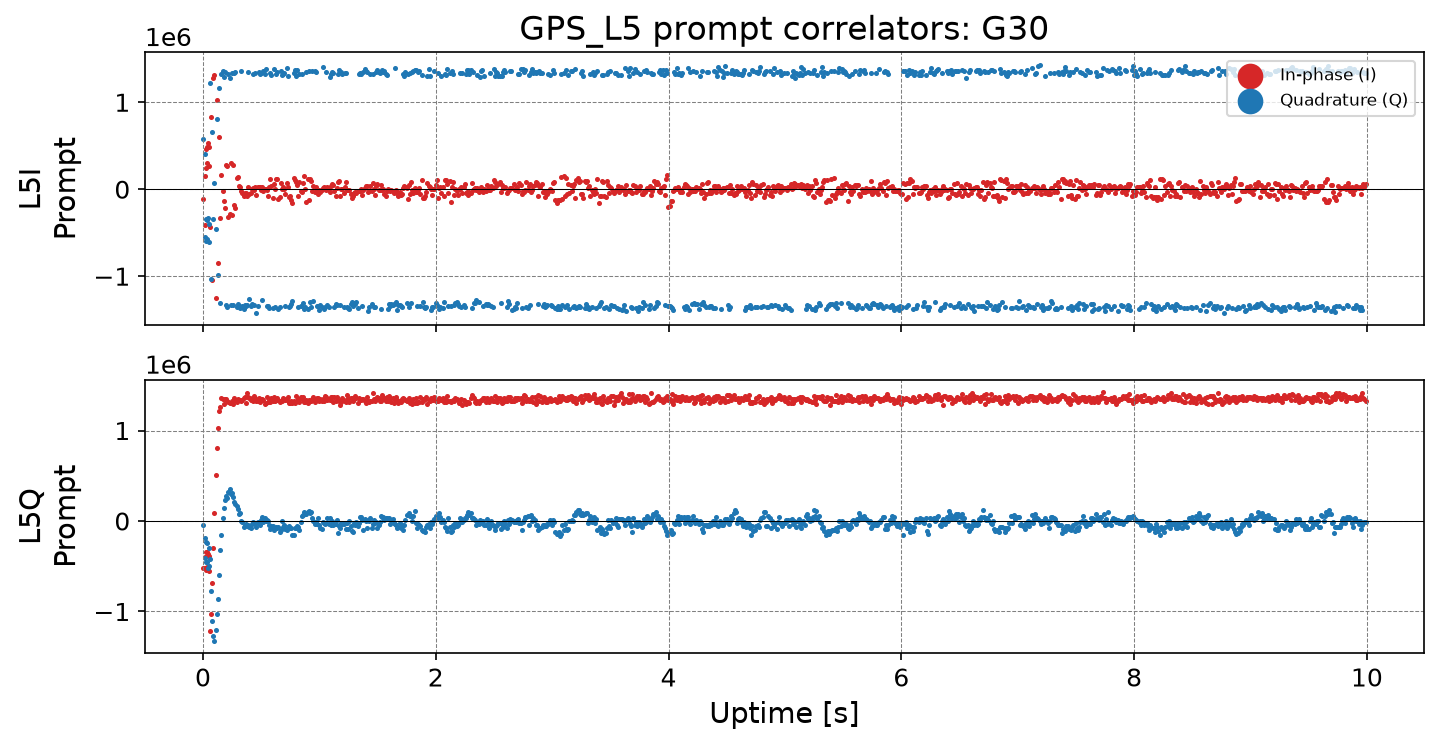

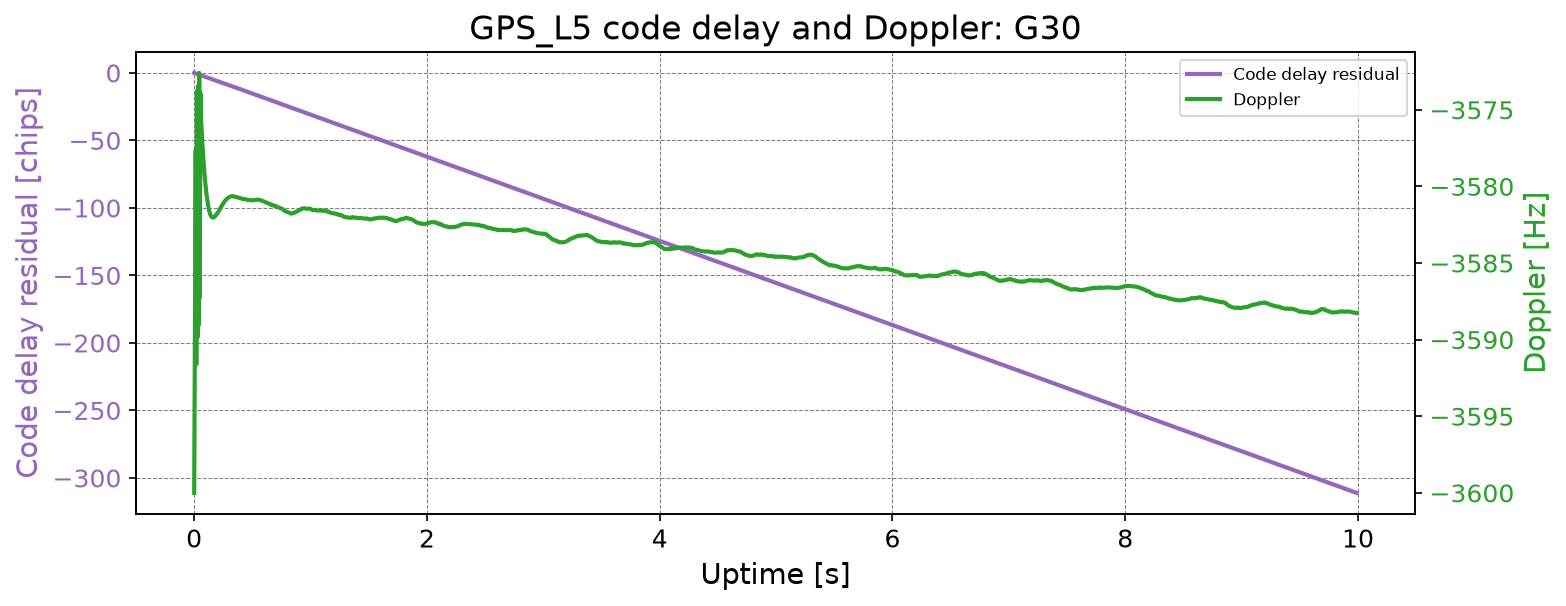

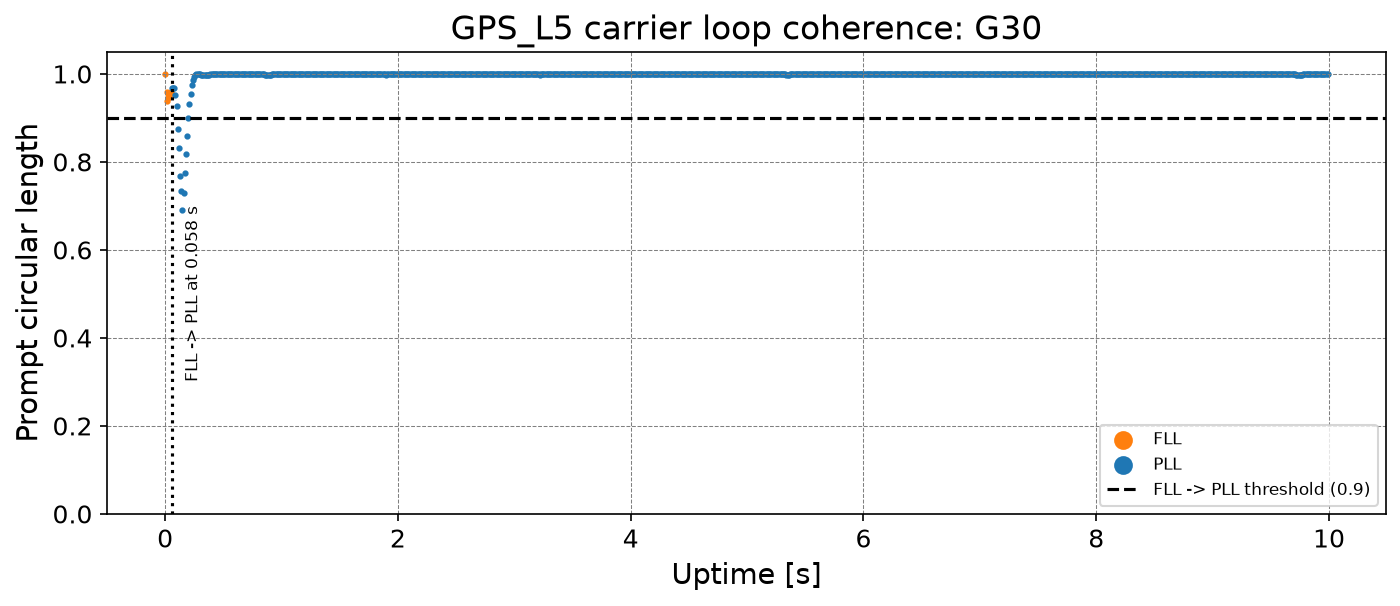

In [9]:
plot_sig_id = acquired_signal_ids[4]  # index into acquired_signal_ids to change
adapter = tracking_channels[plot_sig_id]
num_components = len(adapter.signal.component_names)

# 7.1 Prompt correlator, one row per component, I and Q together.
fig = plt.figure(figsize=(11, 2.6 * num_components), dpi=150)
utils.plotting.plot_prompt_components(
    fig, adapter, plot_sig_id,
    title=f"{SIGNAL_ID.signal_type_id} prompt correlators: {plot_sig_id}",
)

# 7.2 Line-of-sight dynamics: code delay residual against carrier Doppler.
fig2 = plt.figure(figsize=(11, 4), dpi=150)
utils.plotting.plot_code_delay_and_doppler(
    fig2, adapter, plot_sig_id,
    title=f"{SIGNAL_ID.signal_type_id} code delay and Doppler: {plot_sig_id}",
)

# 7.3 Carrier loop coherence, coloured by the loop that filtered each epoch.
fig3 = plt.figure(figsize=(11, 4), dpi=150)
utils.plotting.plot_prompt_circ_length(
    fig3, adapter, plot_sig_id,
    title=f"{SIGNAL_ID.signal_type_id} carrier loop coherence: {plot_sig_id}",
)

plt.show()

---

## Exercises

1. **Loop bandwidth.** Set `PLL_bandwidth_hz` to 5, then 50, and compare the prompt scatter and the Doppler trace.
2. **Start in PLL.** Set `START_TRACKING_IN_PLL_MODE = True` and see which channels fail to pull in from the seed Doppler error printed in step 4.
3. **Fine search.** Set `fine_search_factors=(1, 4)` for your signal and compare the printed Doppler error range — and the acquisition runtime.
4. **A weaker satellite.** Point `plot_sig_id` at the last entry of `acquired_signal_ids`.
5. **A marginal collect.** Set `EXPERIMENT_INDEX = 0`, watch acquisition come up empty, and confirm why in notebook `00`.

## Not covered here

Tracking yields carrier phase and code phase per satellite. A position fix additionally needs the navigation message decoded, ephemerides evaluated, and the pseudoranges solved — none of which this notebook does.